In [1]:
import json

kaggle_dict = {
    "username": "Sathya Mozhi",
    "key": "KGAT_ed55b5d407b9a90ad0b5d55a62af22de"
}

with open("kaggle.json", "w") as file:
    json.dump(kaggle_dict, file)

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d sobhanmoosavi/us-accidents
!unzip us-accidents.zip

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
 98% 637M/653M [00:05<00:00, 66.8MB/s]
100% 653M/653M [00:06<00:00, 100MB/s] 
Archive:  us-accidents.zip
  inflating: US_Accidents_March23.csv  


Original Dataset (First 5 Rows):
    ID   Source  Severity           Start_Time             End_Time  \
0  A-1  Source2         3  2016-02-08 05:46:00  2016-02-08 11:00:00   
1  A-2  Source2         2  2016-02-08 06:07:59  2016-02-08 06:37:59   
2  A-3  Source2         2  2016-02-08 06:49:27  2016-02-08 07:19:27   
3  A-4  Source2         3  2016-02-08 07:23:34  2016-02-08 07:53:34   
4  A-5  Source2         2  2016-02-08 07:39:07  2016-02-08 08:09:07   

   Start_Lat  Start_Lng  End_Lat  End_Lng  Distance(mi)  ... Roundabout  \
0  39.865147 -84.058723      NaN      NaN          0.01  ...      False   
1  39.928059 -82.831184      NaN      NaN          0.01  ...      False   
2  39.063148 -84.032608      NaN      NaN          0.01  ...      False   
3  39.747753 -84.205582      NaN      NaN          0.01  ...      False   
4  39.627781 -84.188354      NaN      NaN          0.01  ...      False   

  Station   Stop Traffic_Calming Traffic_Signal Turning_Loop Sunrise_Sunset  \
0   False 

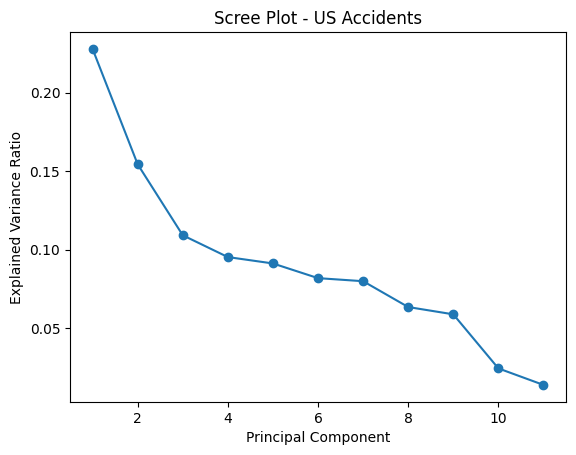


Reduced Dataset (First 5 Rows):
        PC1       PC2
0 -3.298598 -1.692431
1 -3.604066 -1.605427
2 -3.151321 -0.624007
3 -3.671326 -1.373921
4 -3.821716 -0.935005
Reduced Shape: (10000, 2)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer

# ==============================
# STEP 1: Load Dataset
# ==============================
df = pd.read_csv("US_Accidents_March23.csv", nrows=10000)

print("Original Dataset (First 5 Rows):")
print(df.head())
print("\nOriginal Shape:", df.shape)

# ==============================
# STEP 2: Select Numeric Columns
# ==============================
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Remove fully empty columns
numeric_df = numeric_df.dropna(axis=1, how='all')

# Replace infinite values
numeric_df = numeric_df.replace([np.inf, -np.inf], np.nan)

# Impute missing values
imputer = SimpleImputer(strategy='mean')
numeric_clean = imputer.fit_transform(numeric_df)

# Convert back to DataFrame
numeric_clean = pd.DataFrame(numeric_clean, columns=numeric_df.columns)

print("\nCleaned Numeric Dataset (First 5 Rows):")
print(numeric_clean.head())
print("Cleaned Shape:", numeric_clean.shape)

# ==============================
# STEP 3: Standardize Data
# ==============================
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_clean)

# ==============================
# STEP 4: Apply PCA
# ==============================
pca = PCA()
pca.fit(scaled_data)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

# ==============================
# STEP 5: Scree Plot
# ==============================
plt.figure()
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         pca.explained_variance_ratio_,
         marker='o')
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot - US Accidents")
plt.show()

# ==============================
# STEP 6: Reduce to 2 Components
# ==============================
pca_2 = PCA(n_components=2)
reduced_data = pca_2.fit_transform(scaled_data)

# Convert reduced data to DataFrame
reduced_df = pd.DataFrame(reduced_data, columns=["PC1", "PC2"])

print("\nReduced Dataset (First 5 Rows):")
print(reduced_df.head())
print("Reduced Shape:", reduced_df.shape)